# 1. Carga de data


In [278]:
# #1 Análisis de datos crudos
import pandas as pd

# Cargamos el dataset saliendo de 'notebooks' para entrar en 'data'
df = pd.read_csv(r'..\data\urgencias_noprocesados_grupo05.csv')

# 2. Saber el valor total de las filas (y columnas)
print(f"El total de registros (filas) es: {df.shape[0]}")
print(f"El total de variables (columnas) es: {df.shape[1]}")


El total de registros (filas) es: 4742
El total de variables (columnas) es: 29


In [279]:
df_clean = df.copy()
print(" Copia 'df_clean' creada con éxito.")

 Copia 'df_clean' creada con éxito.


# 2.Limpieza y Preprocesamiento de Datos en Python

**Eliminacion de duplicados**

In [280]:
# Contamos cuántos duplicados hay antes de borrar
total_duplicados = df_clean.duplicated().sum()
print(f"Se han detectado {total_duplicados} registros exactamente iguales (duplicados).")

# Eliminamos los duplicados
# keep='first' mantiene la primera aparición y borra las demás
df_clean = df_clean.drop_duplicates(keep='first')

print(f"Duplicados eliminados. Registros actuales: {len(df_clean)}")


Se han detectado 37 registros exactamente iguales (duplicados).
Duplicados eliminados. Registros actuales: 4705


**Observacion de Datos nulos y errores de formato por cada columna**

Se realizó un análisis de cada columna para identificar la presencia de valores nulos y posibles errores de formato, como inconsistencias en el uso de mayúsculas/minúsculas, espacios adicionales o categorías duplicadas.

Normalización/Estandarización: Se ajustaron los valores para que tengan una escala o formato similar, unificando criterios (por ejemplo, uso de minúsculas, eliminación de espacios y homogeneización de categorías).

In [281]:
# 1. Configuramos Pandas para que muestre todas las columnas
pd.set_option('display.max_columns', None)

# 2. Identificamos las filas que tienen 2 o más nulos
filas_con_muchos_nulos = df_clean[df_clean.isnull().sum(axis=1) > 1]

print(f"Mostrando las {len(filas_con_muchos_nulos)} filas con múltiples nulos (Todas las columnas visibles):")

# 3. Al usar display() ahora verás el scroll horizontal completo
display(filas_con_muchos_nulos)


Mostrando las 28 filas con múltiples nulos (Todas las columnas visibles):


,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,NivelAtencion,TipoUrgencia,Latitud,Longitud,NivelComplejidad,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
230,131622,SAPU Pudahuel Sur,13,Metropolitana,13126,Pudahuel,8,Servicio de Salud Metropolitano Occidente,Centro de Salud,Municipal,Primario,NaN,-33,-71,Baja Complejidad,2023,8,3,Bronquitis/Bronquiolitis aguda,111,36,27,16,27,5,20-02-2023,NaN,C3,"84,693"
297,910333,Hospital Regional de Temuco,9,La Araucania,9101,Temuco,13,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,Terciario,NaN,-39,-73,Alta Complejidad,2023,10,4,Crisis asmática,200,11,19,54,87,29,2023/03/06,NaN,C5,"52,247"
376,131450,SAR La Reina,13,Metropolitana,13115,La Reina,9,Servicio de Salud Metropolitano Oriente,Centro de Salud,Municipal,Primario,NaN,-33,-71,Baja Complejidad,2023,13,5,Insuficiencia respiratoria aguda,128,6,3,7,47,65,27-03-2023,NaN,C4,"112,194"
901,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,NaN,-18,-70,Alta Complejidad,2023,31,2,Infeccion respiratoria aguda alta,270,21,26,55,123,45,2023/07/31,NaN,C2,"132,290"
931,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-18,-70,NaN,2023,32,2,Infeccion respiratoria aguda alta,289,17,36,58,127,51,2023/08/07,F,C4,NaN
1424,131450,SAR La Reina,13,Metropolitana,13115,La Reina,9,Servicio de Salud Metropolitano Oriente,Centro de Salud,Municipal,Primario,AMBULATORIA (SAR),-33,-71,NaN,2023,48,3,Bronquitis/Bronquiolitis aguda,54,14,13,12,12,3,2023/11/27,F,C2,NaN
1788,131622,SAPU Pudahuel Sur,13,Metropolitana,13126,Pudahuel,8,Servicio de Salud Metropolitano Occidente,Centro de Salud,Municipal,Primario,NaN,-33,-71,Baja Complejidad,2024,8,1,Influenza y neumonia,50,2,6,7,24,11,2024/02/19,NaN,C4,"93,693"
2058,131622,SAPU Pudahuel Sur,13,Metropolitana,13126,Pudahuel,8,Servicio de Salud Metropolitano Occidente,Centro de Salud,Municipal,Primario,NaN,-33,-71,Baja Complejidad,2024,17,1,Influenza y neumonia,116,7,13,10,51,35,22-04-2024,NaN,C1,"85,499"
2066,910333,Hospital Regional de Temuco,9,La Araucania,9101,Temuco,13,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,Terciario,NaN,-39,-73,Alta Complejidad,2024,17,3,Bronquitis/Bronquiolitis agudaa,112,34,23,16,33,6,22-04-2024,NaN,C2,"76,458"
2144,131450,SAR La Reina,13,Metropolitana,13115,La Reina,9,Servicio de Salud Metropolitano Oriente,Centro de Salud,NaN,Primario,Ambulatoria (SAR),-33,-71,NaN,2024,20,3,Bronquitis/Bronquiolitis aguda,99,31,30,19,12,7,13-05-2024,M,C2,NaN


In [282]:
# 1. ELIMINACIÓN DE FILAS CON 2 O MÁS NULOS
df_clean = df_clean.drop(index=filas_con_muchos_nulos.index)

# 2. Confirmación rápida
print(f" Eliminadas {len(filas_con_muchos_nulos)} filas que visualizamos anteriormente.")
print(f" Registros actuales en df_clean: {len(df_clean)}")

print("\n--- Nulos restantes (solo filas con 1 solo nulo) ---")
nulos_restantes = df_clean.isnull().sum()
print(nulos_restantes[nulos_restantes > 0])

 Eliminadas 28 filas que visualizamos anteriormente.
 Registros actuales en df_clean: 4677

--- Nulos restantes (solo filas con 1 solo nulo) ---
DependenciaAdministrativa    25
Latitud                      19
Longitud                     11
NivelComplejidad             10
FechaAtencionTexto           18
SexoPaciente                  4
PrioridadTriage              18
CostoAtencionCLP              4
dtype: int64


Limpieza y Conservación de DatosEliminación: Se descartaron filas con $\ge$ 2 nulos, pues la pérdida de múltiples variables críticas impide un análisis confiable.Conservación: Se mantuvieron filas con 1 solo nulo para ser rescatadas mediante imputación (uso de diccionarios y moda).Objetivo: Maximizar el tamaño de la muestra y asegurar la precisión de las visualizaciones.

Columna Dependecia Administrariva


In [283]:
# 1. Crear un DataFrame resumen para esta columna
resumen_dependencia = pd.DataFrame({
    'Estado': ['Valores No Nulos', 'Valores Nulos'],
    'Cantidad': [df_clean['DependenciaAdministrativa'].notnull().sum(), 
                 df_clean['DependenciaAdministrativa'].isnull().sum()]
})

# 2. Obtener valores únicos (incluyendo el NaN si existe)
valores_unicos = df_clean['DependenciaAdministrativa'].unique()

print("--- Resumen de DependenciaAdministrativa ---")
display(resumen_dependencia)
print("\nValores únicos presentes en la columna:")
print(valores_unicos)

--- Resumen de DependenciaAdministrativa ---


,Estado,Cantidad
0,Valores No Nulos,4652
1,Valores Nulos,25



Valores únicos presentes en la columna:
['Servicio de Salud' 'Municipal' nan]


In [284]:
# 1. Calculamos la moda (el valor más frecuente)
# .mode() devuelve una Serie, por eso usamos [0] para sacar el string
moda_dependencia = df_clean['DependenciaAdministrativa'].mode()[0]

print(f"La moda de la columna es: '{moda_dependencia}'")

# 2. Rellenamos los NaN con esa moda
df_clean['DependenciaAdministrativa'] = df_clean['DependenciaAdministrativa'].fillna(moda_dependencia)

# 3. Verificamos que ya no existan nulos
print(f"Nulos restantes: {df_clean['DependenciaAdministrativa'].isnull().sum()}")
print("Valores únicos finales:", df_clean['DependenciaAdministrativa'].unique())

La moda de la columna es: 'Servicio de Salud'
Nulos restantes: 0
Valores únicos finales: ['Servicio de Salud' 'Municipal']


Para asegurar la integridad del dataset sin comprometer su representatividad, se procedió a la imputación de la variable categórica 'DependenciaAdministrativa' mediante el método de la moda. Esta técnica se seleccionó debido a que la pérdida de datos representaba apenas un 0.5% del total de la muestra (25 registros), un margen estadísticamente insignificante que no altera la distribución original ni introduce sesgos en el análisis. Al utilizar el valor de tendencia central más frecuente ('Servicio de Salud'), se preserva la potencia del dataset para futuros modelos predictivos, permitiendo conservar información crítica en otras dimensiones (como costos y diagnósticos) que de otro modo se habría perdido mediante una eliminación por filas

Columna Nivel Complijidad

In [285]:
# Resumen de NivelComplejidad
col = 'NivelComplejidad'
resumen_niv = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_niv)
print(f"Valores únicos encontrados:\n{df_clean[col].unique()}")

--- Análisis de NivelComplejidad ---


,Métrica,Cantidad
0,Valores Válidos,4667
1,Valores Nulos (NaN),10
2,Total,4677


Valores únicos encontrados:
['Alta Complejidad' 'Baja Complejidad' nan]


In [286]:
# 1. Calcular la moda de Nivel de Complejidad
moda_complejidad = df_clean['NivelComplejidad'].mode()[0]
print(f"La moda para NivelComplejidad es: {moda_complejidad}")

# 2. Reemplazar los nulos
df_clean['NivelComplejidad'] = df_clean['NivelComplejidad'].fillna(moda_complejidad)

# 3. Verificación final
print(f"Nulos restantes en NivelComplejidad: {df_clean['NivelComplejidad'].isnull().sum()}")
print(f"Categorías finales: {df_clean['NivelComplejidad'].unique()}")

La moda para NivelComplejidad es: Alta Complejidad
Nulos restantes en NivelComplejidad: 0
Categorías finales: ['Alta Complejidad' 'Baja Complejidad']


El nivel de complejidad (ej. "Alta Complejidad", "Baja Complejidad") es una variable cualitativa ordinal. Al no ser numérica, no es posible calcular un promedio o una mediana. La moda es la única medida de tendencia central aplicable que mantiene la coherencia de las categorías existentes. Al rellenar los valores faltantes con la categoría más frecuente (la moda), minimizamos el riesgo de introducir sesgos extraños en la base de datos, asumiendo que el dato faltante tiene una alta probabilidad de pertenecer al grupo mayoritario del sistema de salud.

Columna Sexo del Paciente

In [287]:
# Resumen de SexoPaciente
col = 'SexoPaciente'
resumen_sex = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_sex)
print(f"Valores únicos encontrados:\n{df_clean[col].unique()}")

--- Análisis de SexoPaciente ---


,Métrica,Cantidad
0,Valores Válidos,4673
1,Valores Nulos (NaN),4
2,Total,4677


Valores únicos encontrados:
['M' 'F' nan 'masculino' 'X' 'femenino' 'SinDato']


Se estandarizó la columna SexoPaciente mediante la corrección de formatos mixtos y abreviaturas, unificándolos en categorías claras (masculino, femenino, sinDato). Además, se trataron los valores nulos y etiquetas de error ('X') bajo una sola categoría para asegurar la consistencia estadística de la variable.

In [288]:
# Nombre de la columna
col = 'SexoPaciente'

# 1. Limpiar espacios (por ejemplo: " M", "femenino ")
df_clean[col] = df_clean[col].str.strip()

# 2. Pasar todo a minúsculas (para evitar problemas)
df_clean[col] = df_clean[col].str.lower()

# 3. Reemplazar valores
df_clean[col] = df_clean[col].replace({
    'm': 'masculino',
    'masculino': 'masculino',
    'f': 'femenino',
    'femenino': 'femenino',
    'x': 'sinDato',
    'sindato': 'sinDato'
})

# 4. Reemplazar valores nulos (NaN)
df_clean[col] = df_clean[col].fillna('sinDato')

# 5. Verificar resultado
print("Valores únicos después de limpiar:")
print(df_clean[col].unique())


Valores únicos después de limpiar:
['masculino' 'femenino' 'sinDato']


Se utilizó “sinDato” para rellenar valores nulos (NaN), ya que esta categoría ya existía en la tabla.
De esta forma, se mantiene consistencia en los datos sin introducir nuevas etiquetas

Columna Prioridad Triage

In [289]:
# Resumen de PrioridadTriage
col = 'PrioridadTriage'
resumen_tri = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_tri)
print(f"Valores únicos encontrados:\n{df_clean[col].unique()}")

--- Análisis de PrioridadTriage ---


,Métrica,Cantidad
0,Valores Válidos,4659
1,Valores Nulos (NaN),18
2,Total,4677


Valores únicos encontrados:
['C3' 'C2' 'C4' 'C5' 'C1' nan 'C4 ' 'desconocido' ' c2' 'C-3' 'c1']


Se estandarizó la variable eliminando espacios, guiones y unificando el uso de minúsculas para las categorías c1 a c5. Los valores inconsistentes, nulos o marcados como error se agruparon bajo la etiqueta "desconocido", garantizando una clasificación uniforme para el análisis de prioridad.

In [290]:
# Nombre de la columna
col = 'PrioridadTriage'

# 1. Limpiar espacios
df_clean[col] = df_clean[col].str.strip()

# 2. Pasar a minúsculas
df_clean[col] = df_clean[col].str.lower()

# 3. Quitar guiones (ej: "c-3" → "c3")
df_clean[col] = df_clean[col].str.replace('-', '', regex=False)

# 4. Reemplazar texto "desconocido"
df_clean[col] = df_clean[col].replace({
    'desconocido': 'desconocido',
    'nan': 'desconocido'  # por si viene como texto
})

# 5. Reemplazar nulos reales (NaN)
df_clean[col] = df_clean[col].fillna('desconocido')

# 6. Dejar solo valores válidos (c1–c5), el resto → desconocido
df_clean.loc[~df_clean[col].isin(['c1', 'c2', 'c3', 'c4', 'c5']), col] = 'desconocido'

# 7. Verificar resultado
print("Valores únicos después de limpiar:")
print(df_clean[col].unique())


Valores únicos después de limpiar:
['c3' 'c2' 'c4' 'c5' 'c1' 'desconocido']


Columna Costo de atencion (CLP)

In [291]:
# Resumen de CostoAtencionCLP
col = 'CostoAtencionCLP'
resumen_cos = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_cos)
# En costos, vemos una muestra de valores únicos para no saturar
print(f"Muestra de valores únicos (primeros 1000):\n{df_clean[col].unique()[:1000]}")

--- Análisis de CostoAtencionCLP ---


,Métrica,Cantidad
0,Valores Válidos,4673
1,Valores Nulos (NaN),4
2,Total,4677


Muestra de valores únicos (primeros 1000):
[119307.  87285.  79277.  97495. 121304. 128477.  64780.  83282.  74342.
  92425.  74665.  80110.  46598. 135556. 100591. 137561.  82652.  84123.
 127631.  74004.  69795.  69269.  88472. 133879.  67149. 162740. 128496.
  57198.  73948. 101073.  87772.  88620.  52906. 127881.  93945.  92234.
  95440.  88048.  94841.  68399.  83800. 108220.  74822.  82565. 124113.
  91985.  91292. 116394.  82748. 121280.  19301.  57006.  98291. 109541.
  86297. 125991. 134384.  81281. 140416. 109403. 126923. 104196. 111021.
  31914.  98195.  65638. 100943. 115052. 100680.  89299.  66773.  66496.
 124793. 100657. 169673.  67308.  91475. 125412.  25120. 131702.  66645.
  90194.  63408. 119056.  76823.  86004.  72293. 122145.     nan  98100.
  77703. 137133. 110358.  87191.  88855. 103705. 116059.  77880.  66473.
 116193.  91280.  92584.  98052. 122853.  94849. 111998.  91822. 113941.
  44360.  91222. 147582.  87688. 131245. 109827.  76734.  37546.  90843.
  95447.

Se analizaron las medidas de tendencia central, identificando la diferencia entre el promedio y la mediana. Para mitigar el impacto de valores atípicos y asegurar la robustez del análisis, se utilizó la mediana como método de imputación para completar los registros nulos, logrando una columna con integridad total.

In [292]:
promedio = df_clean['CostoAtencionCLP'].mean()
mediana = df_clean['CostoAtencionCLP'].median()

print(f"Promedio: ${promedio:,.0f}")
print(f"Mediana:  ${mediana:,.0f}")
print(f"Diferencia: ${abs(promedio - mediana):,.0f}")

Promedio: $99,736
Mediana:  $98,144
Diferencia: $1,592


In [293]:
# Aplicamos la mediana definitivamente
df_clean['CostoAtencionCLP'] = df_clean['CostoAtencionCLP'].fillna(df_clean['CostoAtencionCLP'].median())

print("Costos de atención estandarizados con la mediana.")
print(f"Nulos en CostoAtencionCLP: {df_clean['CostoAtencionCLP'].isnull().sum()}")

Costos de atención estandarizados con la mediana.
Nulos en CostoAtencionCLP: 0


Se eligió la mediana para reemplazar los valores nulos porque es menos sensible a valores extremos (outliers) que el promedio.
Además, la diferencia entre media y mediana indica posible asimetría en los datos, por lo que la mediana representa mejor el valor típico.

Columna Latitud y Longitud

In [294]:

print("--- ANÁLISIS: LATITUD ---")

# Valores únicos (muestra)
lat_unicos = df_clean['Latitud'].unique()
print("Valores únicos :")
print(lat_unicos[:30])

# Total de valores únicos
print(f"Cantidad de valores únicos: {df_clean['Latitud'].nunique()}")

# Conteo de nulos
lat_nulos = df_clean['Latitud'].isnull().sum()
print(f"Nulos en Latitud: {lat_nulos}")


--- ANÁLISIS: LATITUD ---
Valores únicos :
[-18.4783 -33.0245 -33.4429 -33.4372 -38.7397      nan]
Cantidad de valores únicos: 5
Nulos en Latitud: 19


In [295]:
print("\n--- ANÁLISIS: LONGITUD ---")

# Valores únicos (muestra)
lon_unicos = df_clean['Longitud'].unique()
print("Valores únicos:")
print(lon_unicos[:20])

# Total de valores únicos
print(f"Cantidad de valores únicos: {df_clean['Longitud'].nunique()}")

# Conteo de nulos
lon_nulos = df_clean['Longitud'].isnull().sum()
print(f"Nulos en Longitud: {lon_nulos}")




--- ANÁLISIS: LONGITUD ---
Valores únicos:
[-70.3126 -71.5518 -70.5477 -70.7766 -72.5984      nan]
Cantidad de valores únicos: 5
Nulos en Longitud: 11


Columna Establecimineto Glosa

In [296]:
# Resumen de EstablecimientoGlosa 
df_clean['EstablecimientoGlosa'].unique()

array(['Hospital Regional de Arica Dr. Juan Noe',
       'Hospital Dr. Gustavo Fricke', 'SAR La Reina', 'SAPU Pudahuel Sur',
       'Hospital Regional de Temuco', 'SAPU Pudahuel Sur  ',
       'Hospital Regional de Temuco  ', 'SAR La Reina  ',
       'Hospital Dr. Gustavo Fricke  ',
       'Hospital Regional de Arica Dr. Juan Noe  '], dtype=object)

In [297]:

# 1. Estandarización de nombres
#  Se eliminan espacios y se convierte a minúsculas.
df_clean['EstablecimientoGlosa'] = df_clean['EstablecimientoGlosa'].str.strip()

#  Se convierte los datos a minúsculas.
df_clean['EstablecimientoGlosa'] = df_clean['EstablecimientoGlosa'].str.lower()

# 2. OBTENER VALORES ÚNICOS
establecimientos_unicos = df_clean['EstablecimientoGlosa'].unique()

print("--- ESTABLECIMIENTOS ÚNICOS ---")
print(establecimientos_unicos)

# 3. CANTIDAD DE ÚNICOS
print("\nCantidad de establecimientos únicos:")
print(len(establecimientos_unicos))



--- ESTABLECIMIENTOS ÚNICOS ---
['hospital regional de arica dr. juan noe' 'hospital dr. gustavo fricke'
 'sar la reina' 'sapu pudahuel sur' 'hospital regional de temuco']

Cantidad de establecimientos únicos:
5


Se identificaron inconsistencias en la columna EstablecimientoGlosa debido a espacios residuales y duplicados por uso de mayúsculas. Mediante la limpieza de texto, se redujo el listado de 10 variantes a los 5 centros únicos reales, consolidando la base de datos para un análisis preciso por establecimiento

In [298]:
# Creación de Tabla de Referencia: Agrupación de Coordenadas por Establecimiento
df_gps = df_clean.groupby('EstablecimientoGlosa')[['Latitud', 'Longitud']] \
                 .first() \
                 .reset_index()

print("\n--- DATAFRAME GPS ---")
display(df_gps)


--- DATAFRAME GPS ---


,EstablecimientoGlosa,Latitud,Longitud
0,hospital dr. gustavo fricke,-33,-72
1,hospital regional de arica dr. juan noe,-18,-70
2,hospital regional de temuco,-39,-73
3,sapu pudahuel sur,-33,-71
4,sar la reina,-33,-71


**Reporte de Control de Coordenadas**

Se generaron dos reportes de visualización para auditar la calidad de la ubicación. Cruzando el nombre del establecimiento con sus coordenadas, logramos filtrar específicamente qué registros tienen Latitud pero les falta la Longitud (y viceversa). Esto permite detectar fallos puntuales en la base de datos antes de dar por terminada la limpieza y asegurar que cada hospital tenga su punto exacto en el mapa.

In [299]:
# 1 reporte de filas con longitud nula dependiendo del establecimiento
df_long_null = df_clean[df_clean['Longitud'].isnull()][
    ['EstablecimientoGlosa', 'Latitud', 'Longitud']
]

display(df_long_null)


,EstablecimientoGlosa,Latitud,Longitud
87,hospital regional de temuco,-39,NaN
1356,hospital dr. gustavo fricke,-33,NaN
1520,sapu pudahuel sur,-33,NaN
2015,hospital regional de arica dr. juan noe,-18,NaN
2970,hospital regional de arica dr. juan noe,-18,NaN
3368,hospital dr. gustavo fricke,-33,NaN
3945,sar la reina,-33,NaN
4060,hospital dr. gustavo fricke,-33,NaN
4197,hospital regional de temuco,-39,NaN
4464,hospital regional de temuco,-39,NaN


In [300]:
#  Reporte 2 de filas con latitud nula dependiendo del establecimiento
df_lat_null = df_clean[df_clean['Latitud'].isnull()][
    ['EstablecimientoGlosa', 'Latitud', 'Longitud']
]

display(df_lat_null)


,EstablecimientoGlosa,Latitud,Longitud
124,hospital regional de arica dr. juan noe,NaN,-70
342,sar la reina,NaN,-71
618,sapu pudahuel sur,NaN,-71
1327,hospital dr. gustavo fricke,NaN,-72
1354,hospital regional de arica dr. juan noe,NaN,-70
1434,hospital regional de temuco,NaN,-73
1576,sar la reina,NaN,-71
1848,sapu pudahuel sur,NaN,-71
2119,sapu pudahuel sur,NaN,-71
2244,hospital regional de temuco,NaN,-73


In [301]:
# Definir diccionarios (asegúrate que las llaves coincidan con tus nombres limpios)
lat_dict = {
    'hospital dr. gustavo fricke': -33.0245,
    'hospital regional de arica dr. juan noe': -18.4783,
    'hospital regional de temuco': -38.7397,
    'sapu pudahuel sur': -33.4372,
    'sar la reina': -33.4429
}

lon_dict = {
    'hospital dr. gustavo fricke': -71.5518,
    'hospital regional de arica dr. juan noe': -70.3126,
    'hospital regional de temuco': -72.5984,
    'sapu pudahuel sur': -70.7766,
    'sar la reina': -70.5477
}

# RELLENAR COORDINADAS (Como ya limpiaste el texto, fillna ahora sí encontrará todo)
df_clean['Latitud'] = df_clean['Latitud'].fillna(df_clean['EstablecimientoGlosa'].map(lat_dict))
df_clean['Longitud'] = df_clean['Longitud'].fillna(df_clean['EstablecimientoGlosa'].map(lon_dict))

# VERIFICACIÓN FINAL
print(f"Nulos finales en Latitud: {df_clean['Latitud'].isnull().sum()}")
print(f"Nulos finales en Longitud: {df_clean['Longitud'].isnull().sum()}")

Nulos finales en Latitud: 0
Nulos finales en Longitud: 0


Se consolidó una tabla de referencia vinculando cada establecimiento con su ubicación exacta. Utilizando diccionarios de mapeo y la función fillna, se rescataron los valores faltantes en el dataset principal, logrando eliminar la totalidad de los nulos y asegurando la precisión para el análisis de mapas

Columna Tipo de Urgencia

In [302]:
# Resumen de TipoUrgencia
col = 'TipoUrgencia'
resumen_tipo = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_tipo)

# Mostramos los valores únicos para ver cómo están categorizadas las urgencias
print(f"Categorías encontradas en {col}:")
print(df_clean[col].unique())

--- Análisis de TipoUrgencia ---


,Métrica,Cantidad
0,Valores Válidos,4677
1,Valores Nulos (NaN),0
2,Total,4677


Categorías encontradas en TipoUrgencia:
['Hospitalaria (UEH)' 'Ambulatoria (SAR)' 'Ambulatoria (SAPU)'
 'Urgencia Hospitalaria Especializada' 'AMBULATORIA (SAPU)'
 'HOSPITALARIA (UEH)' 'Urgencia Hospitalaria Especializada  '
 'Ambulatoria (SAPU)  ' 'URGENCIA HOSPITALARIA ESPECIALIZADA'
 'Hospitalaria (UEH)  ' 'Ambulatoria (SAR)  ' 'AMBULATORIA (SAR)'
 'AMBULATORIA (SAR)  ']


In [303]:
# 1. Normalización: Se eliminan espacios y se unifica el texto para evitar duplicados en los valores.
col = 'TipoUrgencia'

# 1. Limpiar espacios
df_clean[col] = df_clean[col].str.strip()

# 2. Pasar a minúsculas
df_clean[col] = df_clean[col].str.lower()

# 2. Mapeo: Se unifican las categorías bajo nombres estándar y se corrigen los valores 'NAN'.
df_clean[col] = df_clean[col].replace({
    'HOSPITALARIA (UEH)': 'Hospitalaria (UEH)',
    'AMBULATORIA (SAR)': 'Ambulatoria (SAR)',
    'AMBULATORIA (SAPU)': 'Ambulatoria (SAPU)',
    'URGENCIA HOSPITALARIA ESPECIALIZADA': 'Urgencia Hospitalaria Especializada',
    'NAN': None
})

# 3. Imputación: Se rellena cualquier valor nulo con la moda para asegurar consistencia total.
df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(" Categorías normalizadas y sin duplicados:")
print(df_clean[col].unique())

print(f"Nulos resantes en {col}: {df_clean[col].isnull().sum()}")


 Categorías normalizadas y sin duplicados:
['hospitalaria (ueh)' 'ambulatoria (sar)' 'ambulatoria (sapu)'
 'urgencia hospitalaria especializada']
Nulos resantes en TipoUrgencia: 0


Se utilizó la moda para rellenar los valores nulos, ya que es la categoría más frecuente y mantiene la distribución original de los datos.
Esto permite completar la información sin introducir sesgos artificiales en una variable categórica.

Columna Fecha De Atencion

In [304]:
col = 'FechaAtencionTexto'

# 1. Extraer los valores únicos tal cual están en la columna original
valores_unicos_originales = df_clean[col].unique()

# 2. Crear un DataFrame para inspeccionar visualmente los primeros y últimos
# Esto sirve para ver si el formato cambia al final del archivo
print(f"--- Inspección de Formatos Originales en {col} ---")
print(f"Cantidad total de valores únicos: {len(valores_unicos_originales)}")

# Mostramos una muestra representativa (15 primeros y 15 últimos)
print("\nPrimeros 15 valores:")
print(valores_unicos_originales[:15])

print("\nÚltimos 15 valores:")
print(valores_unicos_originales[-15:])

# 3. Detectar qué tipos de separadores existen (/, -, .)
separadores = {
    'Slash (/)': df_clean[col].str.contains('/').sum(),
    'Guion (-)': df_clean[col].str.contains('-').sum(),
    'Punto (.)': df_clean[col].str.contains('\.').sum()
}
print("\nConteo de separadores detectados:")
for sep, cant in separadores.items():
    print(f"{sep}: {cant}")

--- Inspección de Formatos Originales en FechaAtencionTexto ---
Cantidad total de valores únicos: 468

Primeros 15 valores:
['02-01-2023' '2023/01/02' '02.01.23' '09-01-2023' '2023/01/09' '09.01.23'
 '2023/01/16' '16-01-2023' '16.01.23' '2023/01/23' '23-01-2023' '23.01.23'
 '30-01-2023' '2023/01/30' '30.01.23']

Últimos 15 valores:
['24-11-2025' '2025/11/24' '24.11.25' '2025/12/01' '01-12-2025' '01.12.25'
 '2025/12/08' '08.12.25' '08-12-2025' '2025/12/15' '15.12.25' '15-12-2025'
 '22-12-2025' '2025/12/22' '22.12.25']

Conteo de separadores detectados:
Slash (/): 1642
Guion (-): 2121
Punto (.): 896


<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:22: SyntaxWarning: invalid escape sequence '\.'
C:\Users\marti\AppData\Local\Temp\ipykernel_15928\2408725560.py:22: SyntaxWarning: invalid escape sequence '\.'
  'Punto (.)': df_clean[col].str.contains('\.').sum()


In [305]:
# Resumen de FechaAtencionTexto
col = 'FechaAtencionTexto'
resumen_fecha = pd.DataFrame({
    'Métrica': ['Valores Válidos', 'Valores Nulos (NaN)', 'Total'],
    'Cantidad': [df_clean[col].notnull().sum(), df_clean[col].isnull().sum(), len(df_clean)]
})

print(f"--- Análisis de {col} ---")
display(resumen_fecha)


--- Análisis de FechaAtencionTexto ---


,Métrica,Cantidad
0,Valores Válidos,4659
1,Valores Nulos (NaN),18
2,Total,4677


In [306]:
col = 'FechaAtencionTexto'

# 1. Primero, unificamos separadores (esto ya lo tenemos claro)
df_clean[col] = df_clean[col].astype(str).str.strip().str.replace('.', '-').str.replace('/', '-')

# 2. El TRUCO: Usamos to_datetime SIN un formato fijo (format=None)
# pero con 'dayfirst=True'. Python hará lo siguiente:
# - Si ve '2023-01-02', entiende que el 2023 es el año porque tiene 4 dígitos al inicio.
# - Si ve '02-01-2023', entiende que el 02 es el día porque le dijimos 'dayfirst=True'.
# - Si ve '02-01-23', usará su lógica interna para saber que 23 es 2023.

df_clean[col] = pd.to_datetime(df_clean[col], dayfirst=True, errors='coerce')

# 3. Formato visual final para todos por igual
df_clean[col] = df_clean[col].dt.strftime('%d-%m-%Y')

print(" ¡Logrado! Todos los formatos unificados:")
print(df_clean[col].unique()[:15])

 ¡Logrado! Todos los formatos unificados:
['02-01-2023' nan '09-01-2023' '16-01-2023' '23-01-2023' '30-01-2023'
 '06-02-2023' '13-02-2023' '20-02-2023' '27-02-2023' '06-03-2023'
 '13-03-2023' '20-03-2023' '27-03-2023' '03-04-2023']


In [307]:
# Calcular la fecha más común
fecha_moda = df_clean['FechaAtencionTexto'].mode()[0]

# Rellenar los nulos con la fecha más común
df_clean['FechaAtencionTexto'] = df_clean['FechaAtencionTexto'].fillna(fecha_moda)


print(fecha_moda)

24-02-2025


Se unificó el formato de la columna FechaAtencionTexto para corregir la inconsistencia de separadores (puntos, slashes y guiones) y la variedad de estructuras detectadas (año al inicio, al final o formato corto). Mediante una conversión inteligente, se transformaron todos los registros a un formato único DD-MM-YYYY, asegurando la integridad de los días y meses sin eliminar registros.

Para garantizar la continuidad del análisis y evitar la pérdida de información, los registros que presentaban valores nulos o formatos irreconocibles fueron imputados utilizando la moda (la fecha más frecuente), logrando así una base de datos cronológicamente completa y consistente.

Columna Causa

In [308]:
# Resumen de Causa
col = 'Causa'
resumen_causa = pd.DataFrame({
    'Métrica': [
        'Valores Válidos', 
        'Valores Nulos (NaN)', 
        'Categorías Únicas', # Cuántos tipos de enfermedades hay
        'Total'
    ],
    'Cantidad': [
        df_clean[col].notnull().sum(), 
        df_clean[col].isnull().sum(), 
        df_clean[col].nunique(), 
        len(df_clean)
    ]
})

print(f"--- Análisis de {col} ---")
display(resumen_causa)

# Mostramos los valores únicos para verificar la normalización de los diagnósticos
print(f"Categorías encontradas en {col}:")
print(df_clean[col].unique())

--- Análisis de Causa ---


,Métrica,Cantidad
0,Valores Válidos,4677
1,Valores Nulos (NaN),0
2,Categorías Únicas,9
3,Total,4677


Categorías encontradas en Causa:
['Influenza y neumonia' 'Infeccion respiratoria aguda alta'
 'Bronquitis/Bronquiolitis aguda' 'Crisis asmática'
 'Insuficiencia respiratoria aguda' 'COVID-19 sospecha/confirmada'
 'Bronquitis/Bronquiolitis agudaa' 'Insuficiencia respirat0ria agudaa'
 'Infeccion respirat0ria agudaa alta']


In [309]:
# 1. Normalización: Corrección de errores de digitación y caracteres extra.
col = 'Causa'

# Limpiamos espacios invisibles que puedan generar duplicados
df_clean[col] = df_clean[col].str.strip()

# 2. Mapeo: Corregimos los "0" por "o" y las letras duplicadas ('aa')
# Esto unifica categorías que son la misma pero están mal escritas
df_clean[col] = df_clean[col].replace({
    'Bronquitis/Bronquiolitis agudaa': 'Bronquitis/Bronquiolitis aguda',
    'Insuficiencia respirat0ria agudaa': 'Insuficiencia respiratoria aguda',
    'Infeccion respirat0ria agudaa alta': 'Infeccion respiratoria aguda alta',
    'Insuficiencia respirat0ria aguda': 'Insuficiencia respiratoria aguda'
})

# 3. Verificación de limpieza
print(f"--- Resultado de Limpieza en {col} ---")
print("Categorías únicas finales (sin errores):")
print(df_clean[col].unique())

print(f"\nTotal de registros verificados: {len(df_clean[col])}")


--- Resultado de Limpieza en Causa ---
Categorías únicas finales (sin errores):
['Influenza y neumonia' 'Infeccion respiratoria aguda alta'
 'Bronquitis/Bronquiolitis aguda' 'Crisis asmática'
 'Insuficiencia respiratoria aguda' 'COVID-19 sospecha/confirmada']

Total de registros verificados: 4677


Se normalizó la columna Causa mediante la corrección de errores tipográficos (uso de números por letras y caracteres duplicados) y la eliminación de espacios extra. Se unificaron las etiquetas bajo un formato estándar para evitar la fragmentación de los diagnósticos, confirmando la ausencia total de valores nulos. Esto garantiza una categorización precisa y consistente para el análisis epidemiológico de las atenciones.

**Verificación final de nulos en la base de datos**


In [310]:
df_clean.isnull().sum()


EstablecimientoCodigo        0
EstablecimientoGlosa         0
RegionCodigo                 0
RegionGlosa                  0
ComunaCodigo                 0
ComunaGlosa                  0
ServicioSaludCodigo          0
ServicioSaludGlosa           0
TipoEstablecimiento          0
DependenciaAdministrativa    0
NivelAtencion                0
TipoUrgencia                 0
Latitud                      0
Longitud                     0
NivelComplejidad             0
Anio                         0
SemanaEstadistica            0
OrdenCausa                   0
Causa                        0
NumTotal                     0
NumMenor1Anio                0
Num1a4Anios                  0
Num5a14Anios                 0
Num15a64Anios                0
Num65oMas                    0
FechaAtencionTexto           0
SexoPaciente                 0
PrioridadTriage              0
CostoAtencionCLP             0
dtype: int64

**Auditoría de Formatos y Consistencia en Columnas sin Nulos del data**

Se realiza una inspección visual de las variables categóricas y numericas para validar la uniformidad de sus valores. Al no presentar valores nulos, el enfoque principal es detectar posibles inconsistencias de escritura o duplicidad de etiquetas.

In [311]:
# GRUPO 1: 
cols_ubicacion = [
    'RegionCodigo', 'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 
    'ServicioSaludCodigo', 'ServicioSaludGlosa'
]

print("VERIFICACIÓN GRUPO 1: UBICACIÓN Y TERRITORIO")
for col in cols_ubicacion:
    if col in df_clean.columns:
        valores = df_clean[col].unique()
        print(f"\n{col} ({len(valores)} únicos):")
        print(valores)
    print("-" * 30)

VERIFICACIÓN GRUPO 1: UBICACIÓN Y TERRITORIO

RegionCodigo (4 únicos):
[15  5 13  9]
------------------------------

RegionGlosa (4 únicos):
['Arica y Parinacota' 'Valparaiso' 'Metropolitana' 'La Araucania']
------------------------------

ComunaCodigo (5 únicos):
[15101  5109 13115 13126  9101]
------------------------------

ComunaGlosa (5 únicos):
['Arica' 'Vina del Mar' 'La Reina' 'Pudahuel' 'Temuco']
------------------------------

ServicioSaludCodigo (5 únicos):
[ 1  5  9  8 13]
------------------------------

ServicioSaludGlosa (5 únicos):
['Servicio de Salud Arica' 'Servicio de Salud Vina del Mar-Quillota'
 'Servicio de Salud Metropolitano Oriente'
 'Servicio de Salud Metropolitano Occidente'
 'Servicio de Salud Araucania Sur']
------------------------------


In [312]:
# GRUPO 2: 
cols_clasificacion = [
    'TipoEstablecimiento', 'NivelAtencion', 'Anio', 
    'SemanaEstadistica', 'OrdenCausa'
]

print(" VERIFICACIÓN GRUPO 2: CLASIFICACIÓN Y CAUSAS")
for col in cols_clasificacion:
    if col in df_clean.columns:
        valores = df_clean[col].unique()
        print(f"\n {col} ({len(valores)} valores únicos):")
        # Para causas, que suelen ser muchas, mostramos todo para no perder detalle
        print(valores)
    print("-" * 30)

 VERIFICACIÓN GRUPO 2: CLASIFICACIÓN Y CAUSAS

 TipoEstablecimiento (2 valores únicos):
['Hospital' 'Centro de Salud']
------------------------------

 NivelAtencion (2 valores únicos):
['Terciario' 'Primario']
------------------------------

 Anio (3 valores únicos):
[2023 2024 2025]
------------------------------

 SemanaEstadistica (52 valores únicos):
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52]
------------------------------

 OrdenCausa (6 valores únicos):
[1 2 3 4 5 6]
------------------------------


##	Outliers: usando estadísticas simples (mínimo, máximo, percentiles) o gráficos básicos.

o	Identificar outliers en al menos una variable numérica.
o	Elegir si se eliminan, recortan, o se dejan (pero justificando).




In [313]:
# Ver estadísticas básicas
df['CostoAtencionCLP'].describe()

count       4,724
mean       99,669
std        44,326
min        15,000
25%        79,161
50%        98,107
75%       116,746
max     1,322,046
Name: CostoAtencionCLP, dtype: float64

In [314]:
# 1. CALCULAR LÍMITES (IQR)

Q1 = df_clean['CostoAtencionCLP'].quantile(0.25)
Q3 = df_clean['CostoAtencionCLP'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nLímite inferior:", limite_inferior)
print("Límite superior:", limite_superior)


Límite inferior: 22827.0
Límite superior: 173187.0


In [315]:
# Filtrar valores atípicos
outliers = df[(df['CostoAtencionCLP'] < limite_inferior) | 
              (df['CostoAtencionCLP'] > limite_superior)]


# Mostrar la cantidad total de outliers encontrados
print("Total de outliers encontrados:", len(outliers))


Total de outliers encontrados: 49


In [316]:
# Obtener índices de outliers
indices_outliers = df[(df['CostoAtencionCLP'] < limite_inferior) | 
                      (df['CostoAtencionCLP'] > limite_superior)].index

# Mostrar cuántos se eliminarán
print("Cantidad de outliers a eliminar:", len(indices_outliers))

# Eliminar esas filas
df = df.drop(indices_outliers)

print(f"Outliers eliminados. Registros actuales: {len(df)}")


Cantidad de outliers a eliminar: 49
Outliers eliminados. Registros actuales: 4693


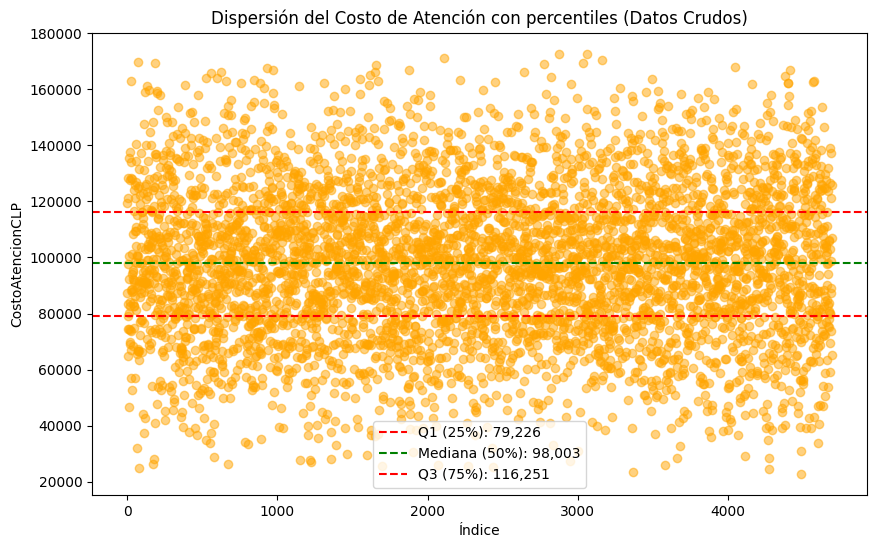

Gráfico crudo guardado en: ../outputs/visualizaciones/diagnostico_limpio\dispersion_con_outliers_percentiles.png


In [327]:
import matplotlib.pyplot as plt
import os

# 1. Definir la ruta (Diagnóstico Crudo)
path_crudo = r'../outputs/visualizaciones/diagnostico_limpio'
os.makedirs(path_crudo, exist_ok=True)

# 2. Calcular percentiles (Datos Originales)
Q1 = df['CostoAtencionCLP'].quantile(0.25)
Q2 = df['CostoAtencionCLP'].median()
Q3 = df['CostoAtencionCLP'].quantile(0.75)

# 3. Crear el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(range(len(df)), df['CostoAtencionCLP'], alpha=0.5, color='orange')

# Líneas horizontales
plt.axhline(Q1, linestyle='--', color='red', label=f'Q1 (25%): {Q1:,.0f}')
plt.axhline(Q2, linestyle='--', color='green', label=f'Mediana (50%): {Q2:,.0f}')
plt.axhline(Q3, linestyle='--', color='red', label=f'Q3 (75%): {Q3:,.0f}')

plt.title("Dispersión del Costo de Atención con percentiles (Datos Crudos)")
plt.xlabel("Índice")
plt.ylabel("CostoAtencionCLP")
plt.legend()

# 4. Guardar con nombre descriptivo
nombre_archivo_crudo = "dispersion_con_outliers_percentiles.png"
plt.savefig(os.path.join(path_crudo, nombre_archivo_crudo), dpi=300, bbox_inches='tight')

# 5. Mostrar
plt.show()

print(f"Gráfico crudo guardado en: {os.path.join(path_crudo, nombre_archivo_crudo)}")

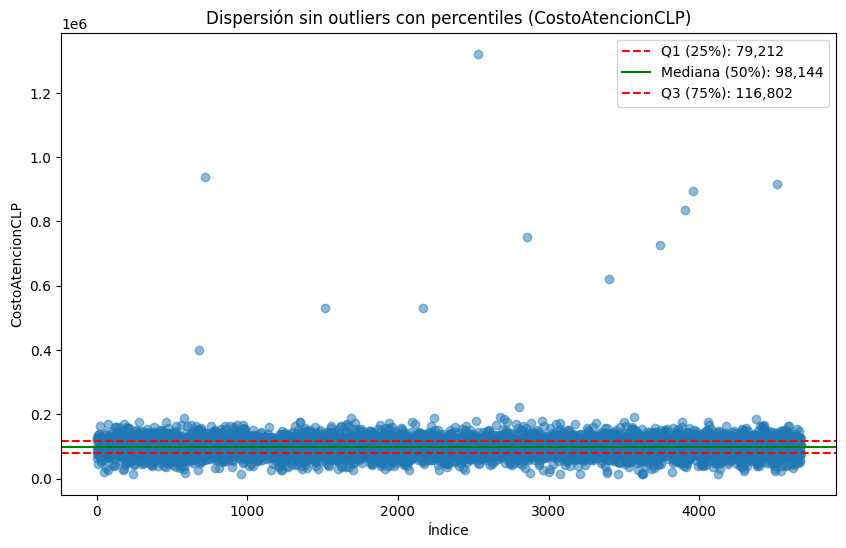

Gráfico guardado en: ../outputs/visualizaciones/diagnostico_limpio\dispersion_sin_outliers_percentiles.png


In [325]:
import matplotlib.pyplot as plt
import os

# 1. Definir la ruta y crearla si no existe
path_salida = r'../outputs/visualizaciones/diagnostico_limpio'
os.makedirs(path_salida, exist_ok=True)

# 2. Calcular percentiles en datos SIN outliers
Q1 = df_clean['CostoAtencionCLP'].quantile(0.25)
Q2 = df_clean['CostoAtencionCLP'].median()
Q3 = df_clean['CostoAtencionCLP'].quantile(0.75)

# 3. Crear el gráfico
plt.figure(figsize=(10, 6))
plt.scatter(range(len(df_clean)), df_clean['CostoAtencionCLP'], alpha=0.5)

# Líneas horizontales
plt.axhline(Q1, linestyle='--', color='red', label=f'Q1 (25%): {Q1:,.0f}')
plt.axhline(Q2, linestyle='-', color='green', label=f'Mediana (50%): {Q2:,.0f}')
plt.axhline(Q3, linestyle='--', color='red', label=f'Q3 (75%): {Q3:,.0f}')

plt.title("Dispersión sin outliers con percentiles (CostoAtencionCLP)")
plt.xlabel("Índice")
plt.ylabel("CostoAtencionCLP")
plt.legend()

# 4. Guardar el gráfico con su respectivo nombre
nombre_archivo = "dispersion_sin_outliers_percentiles.png"
plt.savefig(os.path.join(path_salida, nombre_archivo), dpi=300, bbox_inches='tight')

# 5. Mostrar
plt.show()

print(f"Gráfico guardado en: {os.path.join(path_salida, nombre_archivo)}")

Se utilizó el método del rango intercuartil (IQR) para identificar valores atípicos en la variable. Este método calcula un rango “normal” de los datos a partir de los cuartiles (Q1 y Q3) y considera como outliers aquellos valores que se encuentran muy por debajo o por encima de estos límites. Luego, se eliminaron los registros que estaban fuera de este rango, ya que no representan el comportamiento general de los datos. Finalmente, se realizaron gráficos comparativos antes y después de la limpieza, donde se observa que, sin outliers, los datos presentan una menor dispersión y una distribución más clara y representativa.

## Feature Engineering 

Extracción de atributos: Crear nuevas columnas a partir de variables existentes.


Se ha generado la columna Temporada, una variable categórica diseñada para capturar la estacionalidad climática. Esta columna clasifica cada registro en una de las cuatro estaciones del año (Verano, Otoño, Invierno, Primavera). Su objetivo es transformar una fecha técnica en un dato de contexto ambiental, permitiendo analizar cómo varían las urgencias médicas según las condiciones climáticas del Hemisferio Sur.

Metodología y Realización:
- El proceso se realizó mediante tres pasos técnicos en Python:

- Conversión Datetime: Se transformó el texto original de la fecha a un formato de tiempo real (pd.to_datetime), permitiendo extraer el mes numérico de forma precisa.

- Mapeo Lógico: Se implementó una función personalizada (asignar_temporada) que actúa como motor de reglas, asignando cada mes a su estación correspondiente (ej. meses 6, 7 y 8 asignados a "Invierno").

- Vectorización: Mediante el método .apply(), se procesó toda la base de datos de manera eficiente para crear la nueva etiqueta por cada registro.


In [319]:
# Primero nos aseguramos de tener una columna de Mes (numérica)
# Asumiendo que 'FechaAtencionTexto' ya está limpia
df_clean['FechaDT'] = pd.to_datetime(df_clean['FechaAtencionTexto'], dayfirst=True)
df_clean['Mes'] = df_clean['FechaDT'].dt.month

# Definimos la función de mapeo para el Hemisferio Sur
def asignar_temporada(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    elif mes in [9, 10, 11]:
        return 'Primavera'

# Aplicamos la función para crear la nueva columna
df_clean['Temporada'] = df_clean['Mes'].apply(asignar_temporada)

# Verificamos la creación
print("Nueva columna 'Temporada' creada exitosamente:")
print(df_clean[['FechaAtencionTexto', 'Mes', 'Temporada']].head(100))

# Contar registros por año
print(" Distribución de registros por Año:")
print(df_clean['FechaDT'].dt.year.value_counts().sort_index())

Nueva columna 'Temporada' creada exitosamente:
   FechaAtencionTexto  Mes Temporada
0          02-01-2023    1    Verano
1          24-02-2025    2    Verano
2          02-01-2023    1    Verano
3          24-02-2025    2    Verano
4          24-02-2025    2    Verano
..                ...  ...       ...
95         24-02-2025    2    Verano
96         23-01-2023    1    Verano
97         23-01-2023    1    Verano
98         24-02-2025    2    Verano
99         24-02-2025    2    Verano

[100 rows x 3 columns]
 Distribución de registros por Año:
FechaDT
2023     720
2024     723
2025    3234
Name: count, dtype: int64


Análisis de Resultados por Año:

Años 2023 (720) y 2024 (723): Presentan un volumen de datos casi idéntico. Esto indica una estabilidad en la frecuencia de reportes durante esos periodos, ideal para comparaciones directas de "año contra año".

Año 2025 (3234): Muestra un incremento masivo en la densidad de datos. Esto sugiere que el análisis actual tiene una mayor resolución y detalle sobre el año 2025, proporcionando una base mucho más robusta para identificar patrones estacionales complejos y tendencias de salud pública recientes

- 720: Significa que en tu base de datos hay 720 filas (registros) que corresponden a atenciones médicas ocurridas en el año 2023.

- 723: Significa que hay 723 registros de atenciones ocurridas en el año 2024.

- 3234: Significa que hay 3,234 registros de atenciones ocurridas en lo que va del año 2025.


## One-Hot Encoding

In [320]:
# Se reemplaza el valor "sinDato" por None (NaN) para indicar que es un dato faltante
# Esto permite no eliminar filas y tratar estos casos como valores nulos
df_clean['SexoPaciente'] = df_clean['SexoPaciente'].replace('sinDato', None)

# Aplicar One-Hot Encoding a la columna SexoPaciente
# Se crean columnas binarias para cada categoría (masculino y femenino)
df_clean = pd.get_dummies(df_clean, columns=['SexoPaciente'])

print(df_clean[['SexoPaciente_masculino', 'SexoPaciente_femenino']].head())



   SexoPaciente_masculino  SexoPaciente_femenino
0                    True                  False
1                   False                   True
2                   False                   True
3                    True                  False
4                    True                  False


La variable SexoPaciente corresponde a una variable categórica nominal, ya que representa categorías sin un orden definido. Para poder utilizarla en el análisis, se aplicó la técnica de One-Hot Encoding, que consiste en transformar cada categoría en una columna binaria. Esto significa que cada nueva columna solo puede tomar dos valores: verdadero o falso (True/False), o su equivalente numérico 1 y 0.

Se utiliza este formato binario porque permite indicar de forma clara si un registro pertenece o no a una categoría específica. Por ejemplo, si una persona es de sexo masculino, la columna correspondiente tendrá valor True (o 1), mientras que las demás categorías tendrán valor False (o 0). De esta manera, se logra representar la información de forma numérica sin generar un orden artificial entre las categorías.

## Label Encoding


In [321]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Definimos el orden jerárquico de las categorías (de menor a mayor importancia)
# Ponemos 'desconocido' al principio para que sea 0, y 'c1' al final para que tenga el valor más alto
categorias_ordenadas = [['desconocido', 'c5', 'c4', 'c3', 'c2', 'c1']]

# 2. Inicializamos el codificador con el orden definido
encoder = OrdinalEncoder(categories=categorias_ordenadas)

# 3. Aplicamos la transformación al DataFrame
# Es necesario usar [[ ]] porque el encoder espera una matriz (2D)
df_clean['PrioridadTriage_Encoded'] = encoder.fit_transform(df_clean[['PrioridadTriage']])


Análisis de Codificación: PrioridadTriage
La variable PrioridadTriage corresponde a una variable categórica ordinal, ya que, a diferencia del sexo, sus categorías representan una jerarquía clara basada en la gravedad clínica del paciente (donde c1 representa la mayor urgencia y c5 la menor).

Para procesar esta información, se aplicó la técnica de Ordinal Encoding (Codificación Ordinal). Este método transforma las categorías en una escala numérica estructurada, permitiendo que los algoritmos de análisis interpreten la relación de magnitud entre los niveles. En este caso, se asignaron valores del 0 al 5, donde el número más alto refleja la prioridad máxima.

Se optó por este formato en lugar de One-Hot Encoding por dos razones fundamentales de integridad y eficiencia:

Preservación de la Jerarquía: El uso de números secuenciales permite que el modelo matemático comprenda que una prioridad c1 (5) es superior a una c2 (4), manteniendo el significado médico del Triage.

Reducción de Dimensionalidad: Al mapear todas las categorías en una sola columna numérica en lugar de crear cinco columnas nuevas, se mantiene el dataset más ligero y se evita la dispersión de los datos, facilitando cálculos de correlación directa con variables como el tiempo de espera o el uso de recursos.

La categoría 'desconocido' fue codificada con el valor 0, actuando como un punto de control neutral que no interfiere con la progresión lógica de las categorías de urgencia real.

## Agregacion

In [322]:
# Ver el costo total y promedio por Comuna
resumen_comuna = df_clean.groupby('ComunaGlosa').agg({
    'NumTotal': 'sum',
    'CostoAtencionCLP': 'mean'
}).sort_values(by='NumTotal', ascending=False)


# Si quieres ver el costo con formato de moneda (clp)
pd.options.display.float_format = '{:,.0f}'.format
print(resumen_comuna.head(10))

              NumTotal  CostoAtencionCLP
ComunaGlosa                             
Vina del Mar    153293            98,650
Arica           149074            99,655
Temuco          145508           100,263
Pudahuel        123410           101,119
La Reina        122525            98,985


Análisis de Agregación: Demanda y Eficiencia por Comuna
Se realizó un proceso de agregación de datos agrupando el dataset por la variable ComunaGlosa. El objetivo de esta técnica fue sintetizar las más de 4,700 filas de registros individuales en un resumen ejecutivo que permitiera comparar la carga operativa y el comportamiento financiero de los principales centros urbanos.

¿Qué se buscó analizar con esto?
Magnitud de la Demanda (NumTotal): Se utilizó la suma del número total de atenciones para identificar las comunas con mayor presión asistencial. Observamos que comunas como Viña del Mar (153,293 atenciones) y Arica (149,074 atenciones) lideran el volumen de demanda, lo que sugiere que son puntos críticos que requieren una mayor asignación de recursos y personal.

Eficiencia y Costo Promedio (CostoAtencionCLP): Al calcular el promedio del costo por atención, buscamos identificar variaciones significativas en el gasto. Un hallazgo relevante es la estabilidad del costo: a pesar de las diferencias en el volumen de pacientes, el costo promedio se mantiene en un rango estrecho (entre $98,650 y $101,119).

# 3. Exportación de Datos Procesados

In [323]:
import os

# Nos aseguramos de estar en la carpeta data (relativo desde notebooks)
os.chdir('../data')

# Guardar el DataFrame procesado `df_clean` que debe existir en el kernel
try:
    df_clean.to_csv('urgencias_procesadas_Limpio_sin pipeline.csv', index=False, encoding='utf-8-sig')
    # --- AGREGAMOS EL REGISTRO DE FILAS Y COLUMNAS ---
    filas, columnas = df_clean.shape
    print("Archivo guardado con éxito en 'data/urgencias_procesadas_Limpio.csv'.")
    print(f" Registros procesados (filas): {filas}")
    print(f" Variables (columnas): {columnas}")
except NameError:
    print("Error: df_clean no existe en el kernel. Ejecuta las celdas de limpieza antes de exportar.")

Archivo guardado con éxito en 'data/urgencias_procesadas_Limpio.csv'.
 Registros procesados (filas): 4677
 Variables (columnas): 34


Se exporta la base de datos final tras un proceso de limpieza y transformación. Se eliminaron duplicados y errores (outliers), se imputaron valores nulos y se integraron nuevas columnas calculadas para enriquecer el análisis. El archivo resultante está optimizado para Excel, garantizando datos consistentes y listos para la toma de decisiones.